## **Annotating Images**
In this notebook we will cover how to annotate images using OpenCV. We will learn how to perform the following annotations to images. 

* Draw lines
* Draw circles
* Draw rectangles
* Add text

These are useful when you want to annotate your results for presentations or show a demo of your application. Annotations can also be useful during development and debugging.

In [15]:
import os
import cv2
import matplotlib 
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

matplotlib.rcParams['figure.figsize'] = (9.0, 9.0)
%matplotlib inline
from IPython.display import Image

In [16]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [17]:
URL = r"https://www.dropbox.com/s/48hboi1m4crv1tl/opencv_bootcamp_assets_NB3.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB3.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path) 

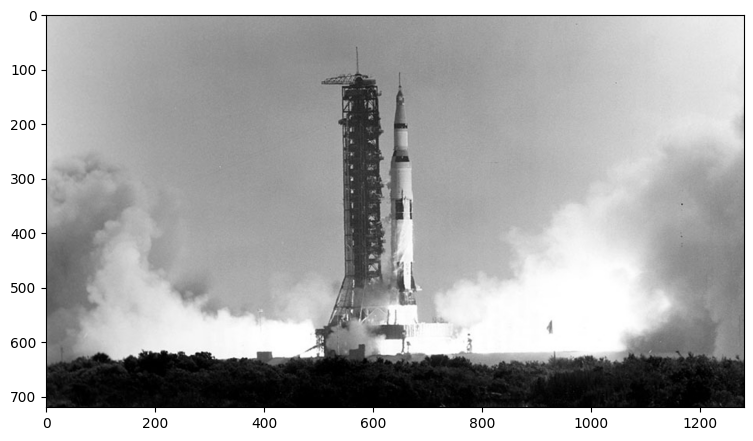

In [18]:
# Read in an image
image = cv2.imread("Apollo_11_launch.jpg", cv2.IMREAD_COLOR)

# Display the original image
plt.imshow(image[:,:,::-1])

## **Drawing a Line**
Let's start off by drawing a line on an image. We will use **cv2.line** function for this.

### <span style="color:green"> Function Syntax
```pytnon
    img = cv2.line(img, pl1, pt2, color[, thickness[, lineType[, shift]]]) 
```
`img`: The output image that has been annotated.

The function has **4 required arguments**:

1. `img`: Image on which we will draw a line.
2. `pt1`: First point(x,y location) of the line segment.
3. `pt2`: Second point of the line segment.
4. `color`: Color of the line which will be drawn.

Other optional arguments that are important for us to know include:

1. `thickness`: Integer specify the line thickness. Default value is 1.
2. `lineType`: Type of the line. Default value is 8 which stands for an 8-connected line. Usually, cv2.LINE_AA(antialiased or smooth line) is used for the lineType.

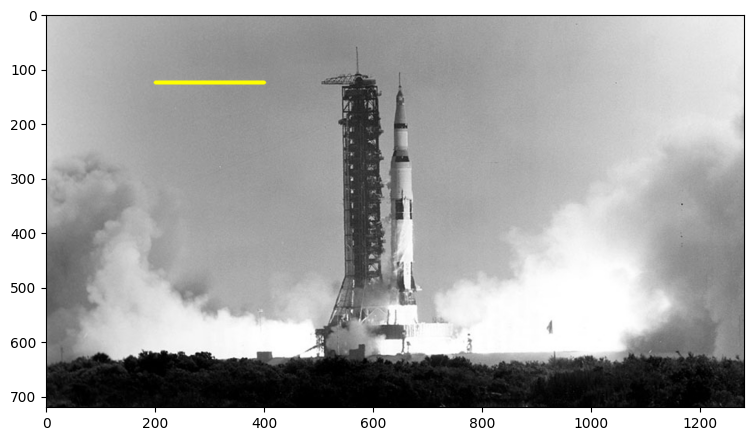

In [19]:
imageLine = image.copy()

# The line starts from (200, 100) and ends at (400, 100).
# The color of the line is YELLOW (recall that OpenCV uses BGR format).
# Thickness of the line is 5px
# Linetype is cv2.LINE_AA

cv2.line(imageLine, (200, 125), (400, 125), (0, 255, 255), thickness=5, lineType=cv2.LINE_AA);

# Display the image
plt.imshow(imageLine[:,:,::-1])


## **Drawing a Circle**
Let's start off by drawing a circle on an image. We will use **cv2.circle** function for this.

### <span style=color:green> Functional syntax
```Python
    img = cv2.circle(img, center, radius, color[, thickness[, lineType[, shift]]])
```
`img`: The output image that has been annotated.

The function has **4 required arguments**:
1. `img`: Image on which we will draw a line.
2. `center`: Center of the circle.
3. `radius`: Radius of the circle.
4. `color`: Color of the circle which will be drawn.

Next, let's check out the (optional) arguments we are going to use quite extensively.

1. `thickness`: Thickness of the circle outline (if positive). if a negative value is supplied for this argument, it will result in a filled circle.
2. `lineType`: Type of the circle boundary. This is exact same as lineType argument in **cv2.line**

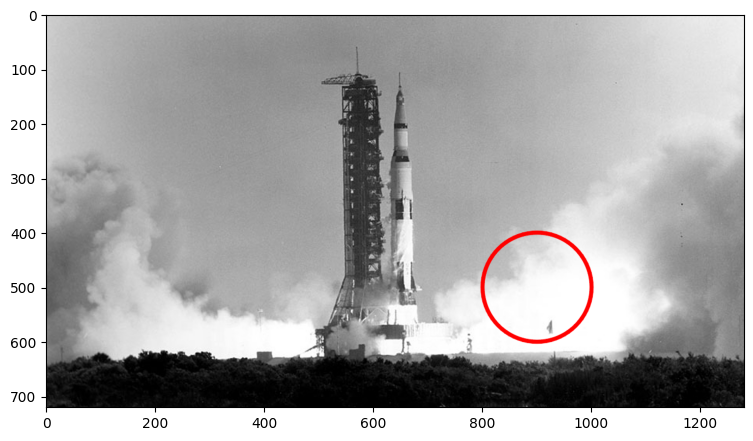

In [20]:
# Draw a circle
imageCircle = image.copy()

cv2.circle(imageCircle, (900, 500), 100, (0, 0, 255), thickness=5, lineType=cv2.LINE_AA)

# Display the image
# plt.imshow(imageCircle)
plt.imshow(imageCircle[:,:,::-1])

## **Drawing a Rectangle**
We will use **cv2.rectangle** function to draw a rectangle on an image. The function syntax is as follows.

### <span style="color:green"> Function syntax
```Python
    img = cv2.rectangle(img, pt1, pt2, color[, thickness[, lineType[, shift]]])
```

`img`: The output image that has been annotated.

The function has **4 required arguments**:

1. `img`: Image on which the rectangle is to be drawn.

2. `pt1`: Vertex of the rectangle. Usually we use the **top-left vertex** here.

3. `pt2`: Vertex of the rectangle opposite to pt1. Usually we use the **bottom-right vertex** here.

4. `color`: Rectangle color

Next, let's check out the (optional) arguments which we are going to use quite extensively.

1. `thickness`: Thickness of the circle outline (if positive). If a negative value is supplied for this argument, it will result in a filled rectangle.

2. `lineType`: Type of the circle boundary. This is exact same as lineType argument in **cv2.line**.


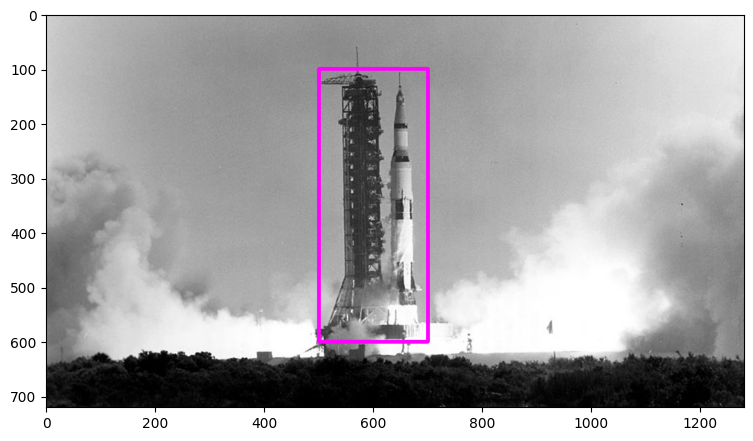

In [21]:
# Draw a rectangle (thickness is a positive integer)
imageRectangle = image.copy()

cv2.rectangle(imageRectangle, (500, 100), (700, 600), (255, 0, 255), thickness=5, lineType=cv2.LINE_8)

# Display the image
plt.imshow(imageRectangle[:, :, ::-1])

## **Adding Text**
Finally, let's see how we can write some text on an image using cv2.putText function.

### <span style="color:green"> Functional syntax
```python
    img = cv2.putText(img, text, org, fontFace, fontScale, color[, thickness[, lineType[, bottomLeftOrigin]]])
```

`img`: The output image that has been annotated.

The function has **6 required arguments**:

1. `img`: Image on which the text has to be written.

2. `text`: Text string to be written.

3. `org`: Bottom-left corner of the text string in the image.

4. `fontFace`: Font type

5. `fontScale`: Font scale factor that is multiplied by the font-specific base size.

6. `color`: Font color

Other optional arguments that are important for us to know include:

1. `thickness`: Integer specifying the line thickness for the text. Default value is 1.

2. `lineType`: Type of the line. Default value is 8 which stands for an 8-connected line. Usually, cv2.LINE_AA (antialiased or smooth line) is used for the lineType.

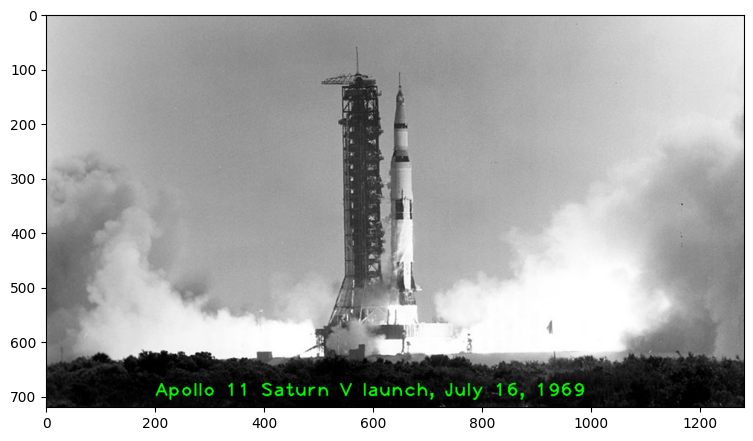

In [24]:
imageText = image.copy()
text = "Apollo 11 Saturn V launch, July 16, 1969"
fontScale = 2.3
fontFace = cv2.FONT_HERSHEY_PLAIN
fontColor = (0, 255, 0)
fontThickness = 2

cv2.putText(imageText, text, (200, 700), fontFace, fontScale, fontColor, fontThickness, lineType=cv2.LINE_AA)

# Display the image
plt.imshow(imageText[:,:,::-1])